# Import libraries and load the processed data

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/gamepulse_players_stage1_clean.csv")

df.head()

,player_id,install_date,country,device_type,acquisition_channel,campaign_name,sessions_day_1,sessions_day_7,total_playtime_minutes,levels_completed,in_app_purchases_gbp,ad_views,retained_day_1,retained_day_7,retained_day_30,churned,basic_player_segment
0,P00001,2026-02-21,India,Android,Facebook Ads,FB_Retargeting,6,8,172.9,12,0.0,13,1,1,0,1,Churned
1,P00002,2026-01-15,United States,Android,Google Ads,GAds_Display,2,2,88.9,5,0.0,5,1,1,0,1,Churned
2,P00003,2026-03-13,India,iOS,Google Ads,GAds_AppInstall,5,3,103.8,10,0.0,6,1,1,0,1,Churned
3,P00004,2026-03-02,Japan,iOS,Google Ads,GAds_Display,4,4,109.8,10,0.0,5,1,1,0,1,Churned
4,P00005,2026-01-21,Canada,Android,Google Ads,GAds_AppInstall,1,0,39.6,6,0.0,0,1,0,0,1,At-Risk Early Drop-off


# Create CRM player segments

In [11]:
def create_crm_segment(row):
    if row["retained_day_30"] == 1 and row["in_app_purchases_gbp"] > 0:
        return "High-Value Retained Player"
    elif row["retained_day_30"] == 1 and row["sessions_day_7"] >= 5:
        return "Loyal Engaged Player"
    elif row["retained_day_1"] == 1 and row["retained_day_7"] == 0:
        return "At-Risk Early Drop-off Player"
    elif row["churned"] == 1:
        return "Churned Player"
    else:
        return "New or Casual Player"

df["crm_segment"] = df.apply(create_crm_segment, axis=1)

df[["player_id", "sessions_day_7", "retained_day_30", "in_app_purchases_gbp", "churned", "crm_segment"]].head()

,player_id,sessions_day_7,retained_day_30,in_app_purchases_gbp,churned,crm_segment
0,P00001,8,0,0.0,1,Churned Player
1,P00002,2,0,0.0,1,Churned Player
2,P00003,3,0,0.0,1,Churned Player
3,P00004,4,0,0.0,1,Churned Player
4,P00005,0,0,0.0,1,At-Risk Early Drop-off Player


# This code creates a new column called:

crm_segment

It groups each player based on their behaviour.

For example:

High-Value Retained Player means the player stayed active and spent money.

Loyal Engaged Player means the player stayed active and played regularly.

At-Risk Early Drop-off Player means the player started but did not continue strongly.

Churned Player means the player did not stay active by Day 30.

New or Casual Player means the player has low or early-stage activity.

# Count players in each CRM segment
This gives the number and percentage of players in each segment.

In [12]:
crm_segment_counts = df["crm_segment"].value_counts().reset_index()

crm_segment_counts.columns = ["crm_segment", "number_of_players"]

crm_segment_counts["percentage"] = (crm_segment_counts["number_of_players"] / len(df) * 100).round(1)

crm_segment_counts

,crm_segment,number_of_players,percentage
0,Churned Player,582,48.5
1,Loyal Engaged Player,258,21.5
2,At-Risk Early Drop-off Player,154,12.8
3,New or Casual Player,112,9.3
4,High-Value Retained Player,94,7.8


# Plot CRM segment distribution
This chart will show which player group is the largest.

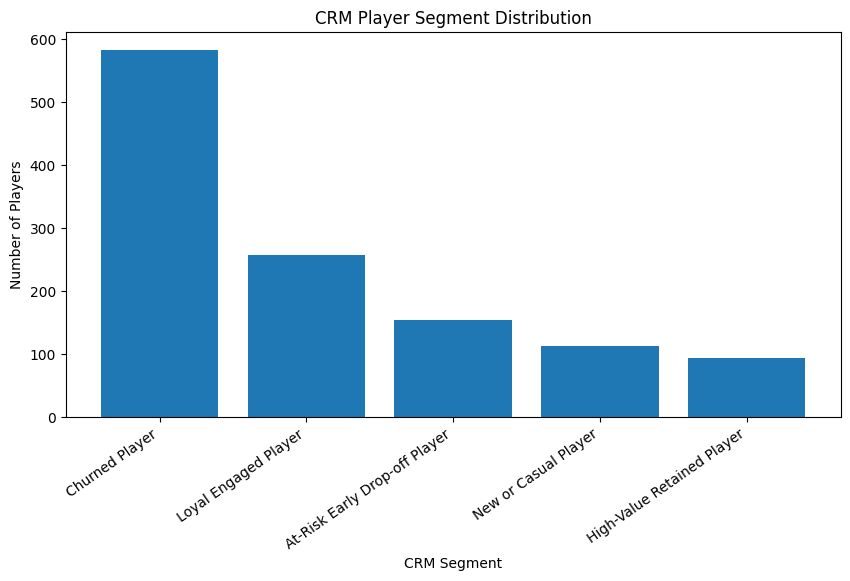

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(crm_segment_counts["crm_segment"], crm_segment_counts["number_of_players"])
plt.title("CRM Player Segment Distribution")
plt.xlabel("CRM Segment")
plt.ylabel("Number of Players")
plt.xticks(rotation=35, ha="right")
plt.show()

# Create a detailed CRM segment summary
This table is important because it shows how each player segment behaves

In [14]:
crm_segment_summary = df.groupby("crm_segment").agg(
    players=("player_id", "nunique"),
    avg_sessions_day_7=("sessions_day_7", "mean"),
    avg_playtime_minutes=("total_playtime_minutes", "mean"),
    avg_levels_completed=("levels_completed", "mean"),
    total_revenue=("in_app_purchases_gbp", "sum"),
    day_30_retention=("retained_day_30", "mean"),
    churn_rate=("churned", "mean")
).reset_index()

crm_segment_summary["avg_sessions_day_7"] = crm_segment_summary["avg_sessions_day_7"].round(1)
crm_segment_summary["avg_playtime_minutes"] = crm_segment_summary["avg_playtime_minutes"].round(1)
crm_segment_summary["avg_levels_completed"] = crm_segment_summary["avg_levels_completed"].round(1)
crm_segment_summary["total_revenue"] = crm_segment_summary["total_revenue"].round(2)
crm_segment_summary["day_30_retention"] = (crm_segment_summary["day_30_retention"] * 100).round(1)
crm_segment_summary["churn_rate"] = (crm_segment_summary["churn_rate"] * 100).round(1)

crm_segment_summary.sort_values("players", ascending=False)

,crm_segment,players,avg_sessions_day_7,avg_playtime_minutes,avg_levels_completed,total_revenue,day_30_retention,churn_rate
1,Churned Player,582,4.7,123.7,8.9,368.37,0.0,100.0
3,Loyal Engaged Player,258,9.4,195.3,13.0,0.00,100.0,0.0
0,At-Risk Early Drop-off Player,154,0.5,56.7,5.0,66.92,17.5,82.5
4,New or Casual Player,112,2.9,97.2,7.7,0.00,100.0,0.0
2,High-Value Retained Player,94,8.4,184.4,12.6,932.06,100.0,0.0


# Revenue by CRM segment
This chart helps show which segment is bringing money into the game.

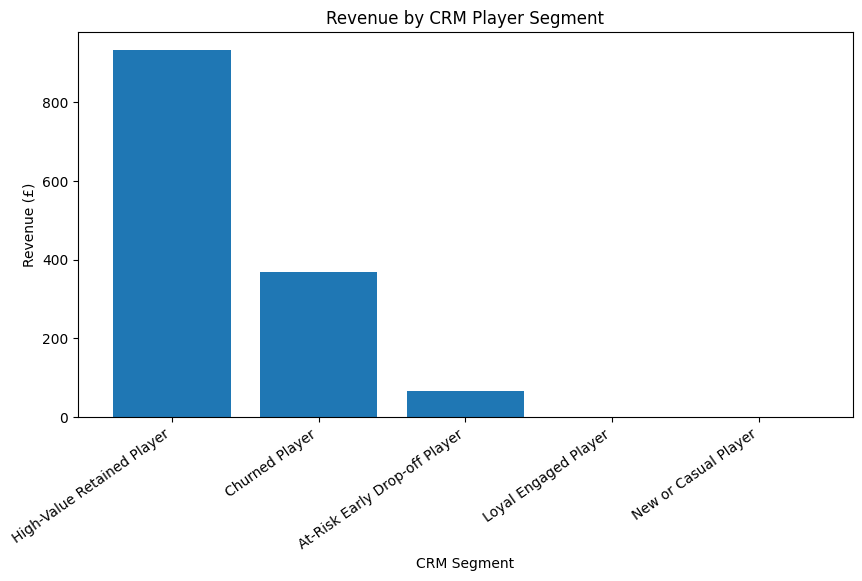

In [15]:
revenue_by_segment = crm_segment_summary.sort_values("total_revenue", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(revenue_by_segment["crm_segment"], revenue_by_segment["total_revenue"])
plt.title("Revenue by CRM Player Segment")
plt.xlabel("CRM Segment")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=35, ha="right")
plt.show()

# for GitHub, the segment names are long. A horizontal chart will look cleaner. Add this optional code:

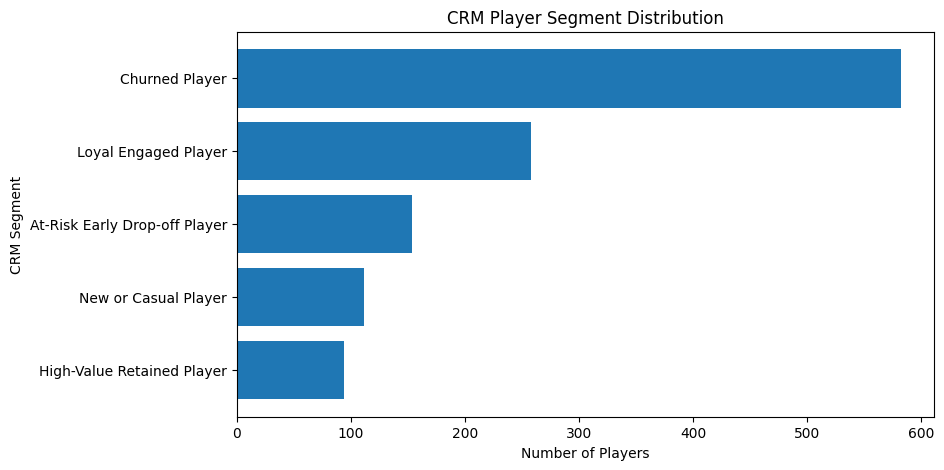

In [16]:
crm_segment_counts_sorted = crm_segment_counts.sort_values("number_of_players")

plt.figure(figsize=(9, 5))
plt.barh(crm_segment_counts_sorted["crm_segment"], crm_segment_counts_sorted["number_of_players"])
plt.title("CRM Player Segment Distribution")
plt.xlabel("Number of Players")
plt.ylabel("CRM Segment")
plt.show()

# for revenue

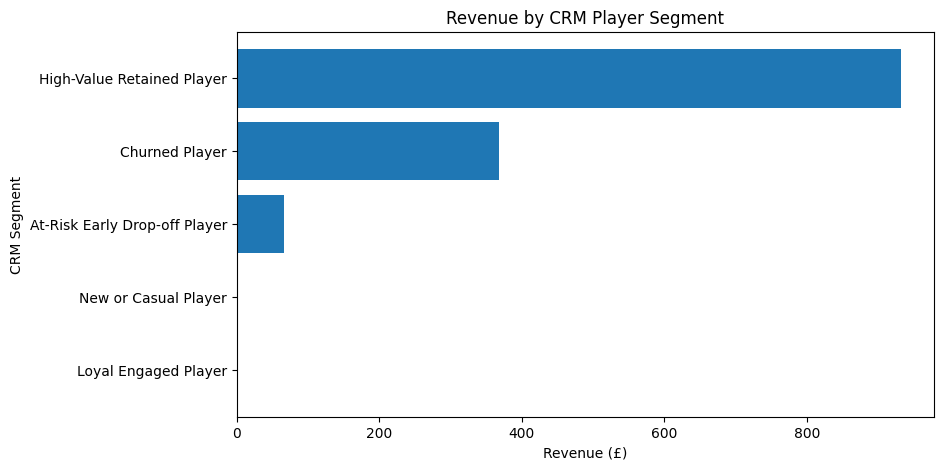

In [17]:
revenue_by_segment_sorted = revenue_by_segment.sort_values("total_revenue")

plt.figure(figsize=(9, 5))
plt.barh(revenue_by_segment_sorted["crm_segment"], revenue_by_segment_sorted["total_revenue"])
plt.title("Revenue by CRM Player Segment")
plt.xlabel("Revenue (£)")
plt.ylabel("CRM Segment")
plt.show()

# Add CRM recommendations
This makes the project look like a real CRM/product analytics project, not just a school analysis.

In [18]:
crm_recommendations = pd.DataFrame({
    "crm_segment": [
        "High-Value Retained Player",
        "Loyal Engaged Player",
        "At-Risk Early Drop-off Player",
        "New or Casual Player",
        "Churned Player"
    ],
    "recommended_action": [
        "Reward with loyalty offers, exclusive content, early access or premium bundles.",
        "Keep engaged with challenges, events, progress rewards and community features.",
        "Send early re-engagement messages, onboarding support, free rewards or reminders.",
        "Use simple tutorials, beginner rewards and personalised prompts to increase engagement.",
        "Use win-back campaigns, special offers or feedback surveys to understand why they left."
    ]
})

crm_recommendations

,crm_segment,recommended_action
0,High-Value Retained Player,"Reward with loyalty offers, exclusive content,..."
1,Loyal Engaged Player,"Keep engaged with challenges, events, progress..."
2,At-Risk Early Drop-off Player,"Send early re-engagement messages, onboarding ..."
3,New or Casual Player,"Use simple tutorials, beginner rewards and per..."
4,Churned Player,"Use win-back campaigns, special offers or feed..."


# Join segment summary with recommendations
This creates a full action plan for the business.

In [19]:
crm_action_plan = crm_segment_summary.merge(crm_recommendations, on="crm_segment", how="left")

crm_action_plan.sort_values("players", ascending=False)

,crm_segment,players,avg_sessions_day_7,avg_playtime_minutes,avg_levels_completed,total_revenue,day_30_retention,churn_rate,recommended_action
1,Churned Player,582,4.7,123.7,8.9,368.37,0.0,100.0,"Use win-back campaigns, special offers or feed..."
3,Loyal Engaged Player,258,9.4,195.3,13.0,0.00,100.0,0.0,"Keep engaged with challenges, events, progress..."
0,At-Risk Early Drop-off Player,154,0.5,56.7,5.0,66.92,17.5,82.5,"Send early re-engagement messages, onboarding ..."
4,New or Casual Player,112,2.9,97.2,7.7,0.00,100.0,0.0,"Use simple tutorials, beginner rewards and per..."
2,High-Value Retained Player,94,8.4,184.4,12.6,932.06,100.0,0.0,"Reward with loyalty offers, exclusive content,..."


# Save Stage 3 results

In [20]:
import os

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

df.to_csv("../data/processed/gamepulse_players_with_crm_segments.csv", index=False)

crm_segment_counts.to_csv("../reports/stage3_crm_segment_counts.csv", index=False)
crm_segment_summary.to_csv("../reports/stage3_crm_segment_summary.csv", index=False)
crm_action_plan.to_csv("../reports/stage3_crm_action_plan.csv", index=False)

print("Stage 3 CRM segmentation files saved successfully.")

Stage 3 CRM segmentation files saved successfully.


## Stage 3 Business Insight: CRM Player Segmentation

The CRM segmentation analysis grouped players based on retention, engagement and purchase behaviour. This helps the business understand that not all players should be treated the same. Some players are already valuable and should be rewarded, while others are at risk of leaving and need early re-engagement.

High-value retained players are important because they remain active and generate revenue. Loyal engaged players are also valuable because they show strong gameplay behaviour, even if they may not always spend money. At-risk early drop-off players are a key CRM opportunity because they showed some initial interest but did not continue strongly. These players should receive targeted onboarding support, reminders or rewards before they fully churn.

The churned player group shows where the business is losing users. This segment may need win-back campaigns or further research to understand why players stopped playing. Overall, CRM segmentation allows the company to move away from general marketing and use more targeted, data-driven player engagement strategies.